In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import levene

Transformation of data - Normalisering

**2-way-ANOVA**


Assumptions: Homogeneity of variance, Independence of observations, Normally-distributed dependent variable 


Dataset overview
      answer_key_id true_mistakes                prompt_type  \
0  errors_00_key_01             0  prompt_1_very_pessimistic   
1  errors_00_key_01             0       prompt_2_pessimistic   
2  errors_00_key_01             0           prompt_3_neutral   
3  errors_00_key_01             0         prompt_4_confident   
4  errors_00_key_01             0    prompt_5_very_confident   

   ai_estimated_mistakes  ai_error  
0                      1         1  
1                      0         0  
2                      0         0  
3                      0         0  
4                      0         0  

Number of observations:
2400

Mean AI error by true_mistakes and prompt_type:
prompt_type    prompt_1_very_pessimistic  prompt_2_pessimistic  \
true_mistakes                                                    
0                               0.700000              0.566667   
1                               0.966667              0.566667   
2                               

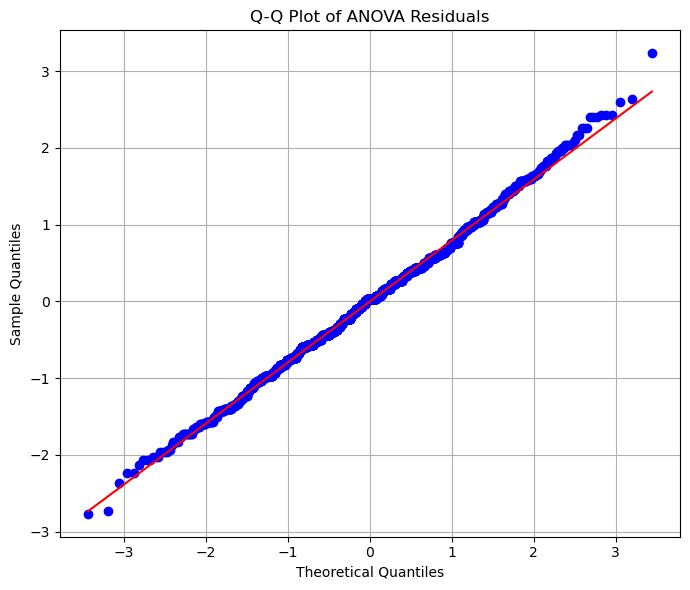

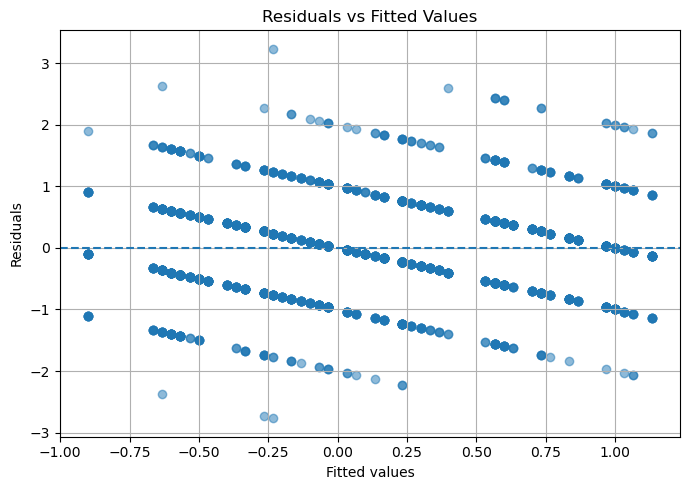


Levene's test for equal variances
Statistic: 2.4351
p-value:   0.0000
Possible violation of equal variances.


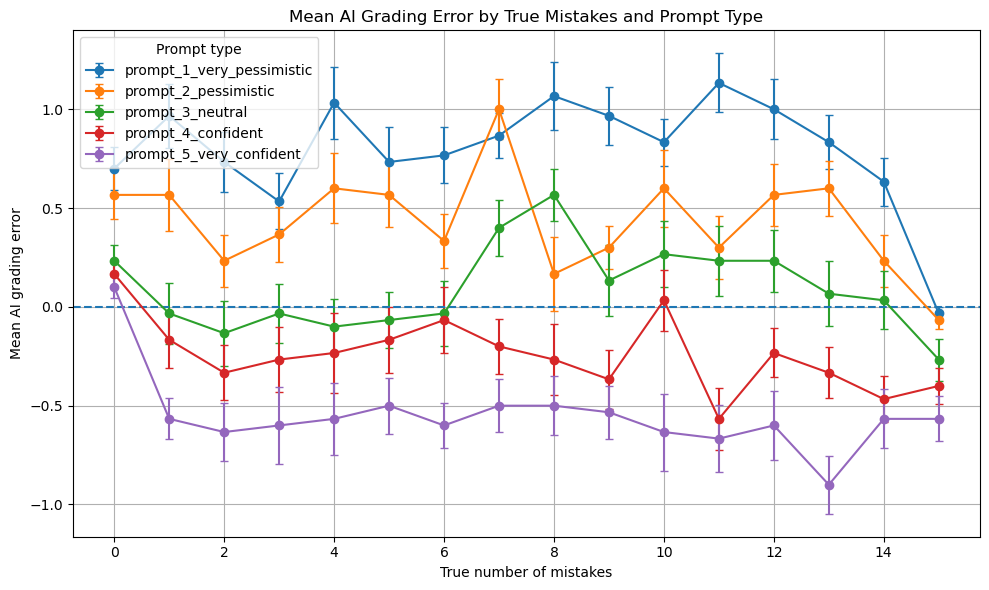

In [5]:
# Replace with our file path
df = pd.read_csv("ai_grading_experiment.csv")

# Required columns:
required_columns = [
    "answer_key_id",
    "true_mistakes",
    "prompt_type",
    "ai_estimated_mistakes"
]

# Dependent variable:
# Positive ai_error = AI overestimates number of mistakes
# Negative ai_error = AI underestimates number of mistakes
# Zero ai_error = AI estimates perfectly

df["ai_error"] = df["ai_estimated_mistakes"] - df["true_mistakes"]

df["true_mistakes"] = df["true_mistakes"].astype("category")
df["prompt_type"] = df["prompt_type"].astype("category")

# Basic descriptive statistics

print("\n==============================")
print("Dataset overview")
print("==============================")
print(df.head())

print("\nNumber of observations:")
print(len(df))

print("\nMean AI error by true_mistakes and prompt_type:")
means_table = df.groupby(
    ["true_mistakes", "prompt_type"],
    observed=False
)["ai_error"].mean().unstack()

print(means_table)


# Two-way ANOVA model
# Model: ai_error ~ true_mistakes + prompt_type + true_mistakes:prompt_type

model = smf.ols(
    "ai_error ~ C(true_mistakes) * C(prompt_type)",
    data=df
).fit()

anova_table_type2 = sm.stats.anova_lm(model, typ=2)

print("\n==============================")
print("Two-way ANOVA table")
print("==============================")
print(anova_table_type2)


# Assumption check 1 (Normality): Q-Q plot of residuals

residuals = model.resid

plt.figure(figsize=(7, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of ANOVA Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

# Assumption check 2 (Homoscedasticity): residuals vs fitted values

fitted_values = model.fittedvalues

plt.figure(figsize=(7, 5))
plt.scatter(fitted_values, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.grid(True)
plt.tight_layout()
plt.show()

# Assumption check 3 (Equal variances): Levene's test for equal variances

groups = [
    group["ai_error"].dropna().values
    for _, group in df.groupby(["true_mistakes", "prompt_type"], observed=False)
]

levene_stat, levene_p = levene(*groups)

print("\n==============================")
print("Levene's test for equal variances")
print("==============================")
print(f"Statistic: {levene_stat:.4f}")
print(f"p-value:   {levene_p:.4f}")

if levene_p > 0.05:
    print("No significant evidence against equal variances.")
else:
    print("Possible violation of equal variances.")



# Plot of mean AI error across true mistake levels by prompt

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("ai_error", "mean"),
        sd_ai_error=("ai_error", "std"),
        n=("ai_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])

# Converting true_mistakes back to numeric for plotting
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["se_ai_error"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )

plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()

# Saved results:

anova_table_type2.to_csv("anova_type2_results.csv")
summary.to_csv("anova_group_summary.csv", index=False)


**Post-hoc Analysis**

pairwise_tukeyhsd is a statistical post-hoc test used to determine which specific groups differ from each other after a significant ANOVA. It performs all pairwise comparisons between group means.

In [7]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD post-hoc test between prompt types
tukey_prompt = pairwise_tukeyhsd(
    endog=df["ai_error"],
    groups=df["prompt_type"],
    alpha=0.05
)
print(tukey_prompt)

                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
          group1                   group2         meandiff p-adj  lower   upper  reject
---------------------------------------------------------------------------------------
prompt_1_very_pessimistic    prompt_2_pessimistic  -0.3646   0.0   -0.51 -0.2192   True
prompt_1_very_pessimistic        prompt_3_neutral  -0.7042   0.0 -0.8496 -0.5588   True
prompt_1_very_pessimistic      prompt_4_confident  -1.0396   0.0  -1.185 -0.8942   True
prompt_1_very_pessimistic prompt_5_very_confident    -1.35   0.0 -1.4954 -1.2046   True
     prompt_2_pessimistic        prompt_3_neutral  -0.3396   0.0  -0.485 -0.1942   True
     prompt_2_pessimistic      prompt_4_confident   -0.675   0.0 -0.8204 -0.5296   True
     prompt_2_pessimistic prompt_5_very_confident  -0.9854   0.0 -1.1308   -0.84   True
         prompt_3_neutral      prompt_4_confident  -0.3354   0.0 -0.4808   -0.19   True
         prompt_3_neutral prompt